# Milestone 1: Formula 1 podium prediction

**Course:** CSEN 903 Advanced Computer Lab, GUC, Winter 2026

**Team:**

**The question we answer:** for one driver in one race, will he finish in the top 3?

**When we answer it:** after qualifying and before the race starts. This moment is our *cutoff*. Anything recorded after it (finishing position, points, laps, pit stops, status, updated standings) is the answer sheet of the exam. If the model sees it, that is *data leakage* and the scores mean nothing.

**How this notebook is organised**

| Section | What happens | Brief objective |
|---|---|---|
| 0 | Setup and loading | Run-all requirement |
| 1 | Audit and EDA before cleaning | 1 |
| 2 | Cleaning, then EDA again | 1 |
| 3 | One joined table, one row per driver per race | 1 |
| 4 | The three data-engineering questions | 2 |
| 5 | Feature engineering with leakage tests | 3 |
| 6 | Split, preprocessing, order experiments | 3 |
| 7 | Models and evaluation | 4 |
| 8 | Feature-group ablation | 5 |
| 9 | Explainability (permutation importance, SHAP, LIME) | 6 |
| 10 | Inference function | Deliverable 7 |
| 11 | Summary, limitations, checklist | Report |

Every section follows the same pattern: what we do, why we do it, the code, then what we see in the output.

In [2]:
# --- Standard libraries ---
import os, sys, glob, random, hashlib, warnings, subprocess, importlib, time
warnings.filterwarnings('ignore')                      # keep the notebook output readable

# --- Data and plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display


# --- Machine learning ---
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, confusion_matrix,
                             roc_curve, precision_recall_curve)

# --- Neural network ---
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')   # hide TensorFlow start-up messages
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


# --- Explainability ---
import shap
import lime.lime_tabular

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

# --- Reproducibility: one seed for everything ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print('pandas', pd.__version__, '| numpy', np.__version__, '| tensorflow', tf.__version__, '| shap', shap.__version__)

pandas 2.3.3 | numpy 2.1.3 | tensorflow 2.20.0 | shap 0.52.0


In [3]:
# --- One plotting style for the whole notebook, so every chart reads the same way ---
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'     # main colours, used in this fixed order
LIGHT_BLUE, GREY, RED = '#9ec5f4', '#9a9a95', '#d03b3b'  # "before / reference", neutral, warning

plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e6e3', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.frameon': False,
})

FIG_DIR = 'figures'              # every chart is also saved here, ready for the PDF report
os.makedirs(FIG_DIR, exist_ok=True)

def finish(fig, name):
    """Tidy the layout, save the chart as a PNG, and show it."""
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, name + '.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def pct(x, digits=1):
    """Format a share as a percentage string."""
    return f'{100 * x:.{digits}f}%'

In [4]:
import os
import pandas as pd

# The Kaggle dataset path
DATA_DIR = '/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020'

# The 14 table names
TABLES = [
    'circuits', 'constructors', 'constructor_results', 'constructor_standings', 
    'drivers', 'driver_standings', 'races', 'results', 'qualifying', 
    'lap_times', 'pit_stops', 'sprint_results', 'seasons', 'status'
]

# Load all tables into a dictionary as strings
raw = {}
for t in TABLES:
    file_path = os.path.join(DATA_DIR, t + '.csv')
    raw[t] = pd.read_csv(file_path, dtype=str, keep_default_na=False)

print('Successfully loaded tables:', len(raw))

Successfully loaded tables: 14


In [5]:
# To look at the first few rows of the drivers table
print(raw['drivers'].head())

# To look at the circuits table
print(raw['circuits'].head())

  driverId   driverRef number code  forename     surname         dob nationality                                             url
0        1    hamilton     44  HAM     Lewis    Hamilton  1985-01-07     British     http://en.wikipedia.org/wiki/Lewis_Hamilton
1        2    heidfeld     \N  HEI      Nick    Heidfeld  1977-05-10      German      http://en.wikipedia.org/wiki/Nick_Heidfeld
2        3     rosberg      6  ROS      Nico     Rosberg  1985-06-27      German       http://en.wikipedia.org/wiki/Nico_Rosberg
3        4      alonso     14  ALO  Fernando      Alonso  1981-07-29     Spanish    http://en.wikipedia.org/wiki/Fernando_Alonso
4        5  kovalainen     \N  KOV    Heikki  Kovalainen  1981-10-19     Finnish  http://en.wikipedia.org/wiki/Heikki_Kovalainen
  circuitId   circuitRef                            name      location    country       lat      lng  alt                                                url
0         1  albert_park  Albert Park Grand Prix Circuit     Melbourn

# 1. Audit and EDA before cleaning
Before we change anything we want to answer a very basic question: **"WHAT EXACTLY IS IN THE DATASET FILES AND WHAT IS WRONG WITH THESE FILES ?"**. Since EDA cannot be done by looking at the data by eye, so every statement in this section comes from code and has a table or a chart.

## 1.1 What do the 14 tables look like?
**What we do**: count rows and columns per table, and count the two kinds of placeholder for "missing": the text \N and the empty string.

**Why**: this tells us where the data lives (which tables are big), which tables need cleaning, and which table might be potentially our modelling table.

,table,rows,columns,cells equal to \N,empty cells
0,lap_times,589081,6,0,0
1,driver_standings,34863,7,0,0
2,results,26759,18,122887,0
3,constructor_standings,13391,7,0,0
4,constructor_results,12625,5,12608,0
5,pit_stops,11371,7,0,0
6,qualifying,10494,9,11600,68
7,races,1125,18,11349,0
8,drivers,861,9,1559,0
9,sprint_results,360,16,73,0


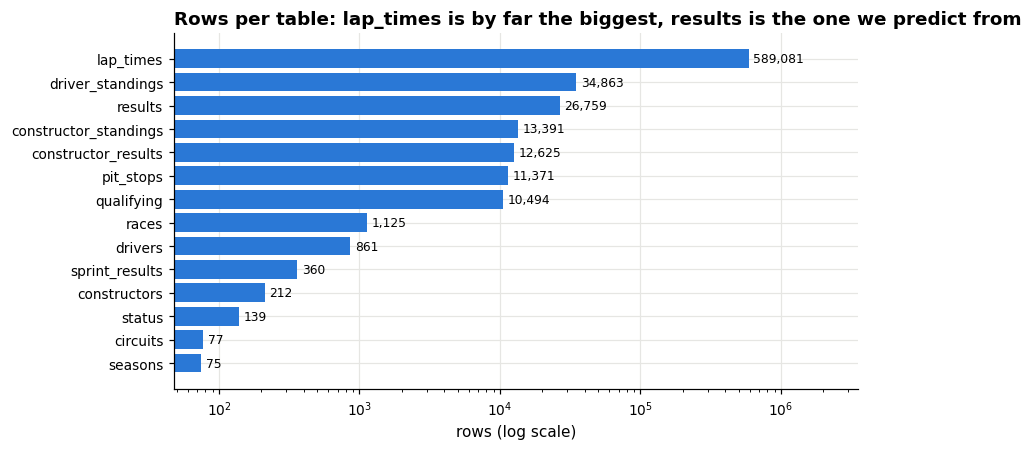

In [6]:
# One line per table: its size and how many placeholder cells it contains
overview = pd.DataFrame([{
    'table': t,
    'rows': len(df),
    'columns': df.shape[1],
    r'cells equal to \N': int((df == '\\N').sum().sum()),
    'empty cells': int((df == '').sum().sum()),
} for t, df in raw.items()]).sort_values('rows', ascending=False).reset_index(drop=True)
display(overview)

# Bar chart of the table sizes. The axis is logarithmic because lap_times is about 20 times bigger than results
fig, ax = plt.subplots(figsize=(8, 4.2))
o = overview.sort_values('rows')
bars = ax.barh(o['table'], o['rows'], color=BLUE)
ax.set_xscale('log')
ax.bar_label(bars, labels=[f'{v:,}' for v in o['rows']], padding=3, fontsize=8)
ax.set_xlabel('rows (log scale)')
ax.set_title('Rows per table: lap_times is by far the biggest, results is the one we predict from')
ax.set_xlim(right=o['rows'].max() * 6)
finish(fig, '01_rows_per_table')

## 1.2 How the tables link together

Now that subsection 1.1 told us what tables exist and how large they are, subsection 1.2 answers the next critical question: 
"**HOW ARE THESE 14 TABLES CONNECTED TO EACH OTHER ?**" 
This is exactly what we are answering in this subsection. 

**Why:** We know that the data is relational. Before joining we need to know which column identifies a row in each table (its primary key) and which columns point to another table (foreign keys). We write both down once, here, and the table below is our map for the rest of the notebook.

This is extremely important because our final modeling dataset will have to combine information from several tables. If we don't understand the keys and relationships first, we can easily create incorrect joins, duplicate rows, or lose observations.

In [7]:
# Primary key of every table, and every foreign key (child column -> parent table)
PRIMARY_KEYS = {
    'circuits': ['circuitId'], 'constructors': ['constructorId'], 'drivers': ['driverId'],
    'races': ['raceId'], 'seasons': ['year'], 'status': ['statusId'],
    'results': ['resultId'], 'qualifying': ['qualifyId'], 'sprint_results': ['resultId'],
    'driver_standings': ['driverStandingsId'], 'constructor_standings': ['constructorStandingsId'],
    'constructor_results': ['constructorResultsId'],
    'lap_times': ['raceId', 'driverId', 'lap'],      # composite key: no single id column
    'pit_stops': ['raceId', 'driverId', 'stop'],     # composite key
}
FOREIGN_KEYS = [  # (child table, column, parent table)
    ('races', 'circuitId', 'circuits'), ('races', 'year', 'seasons'),
    ('results', 'raceId', 'races'), ('results', 'driverId', 'drivers'),
    ('results', 'constructorId', 'constructors'), ('results', 'statusId', 'status'),
    ('qualifying', 'raceId', 'races'), ('qualifying', 'driverId', 'drivers'), ('qualifying', 'constructorId', 'constructors'),
    ('sprint_results', 'raceId', 'races'), ('sprint_results', 'driverId', 'drivers'),
    ('sprint_results', 'constructorId', 'constructors'), ('sprint_results', 'statusId', 'status'),
    ('driver_standings', 'raceId', 'races'), ('driver_standings', 'driverId', 'drivers'),
    ('constructor_standings', 'raceId', 'races'), ('constructor_standings', 'constructorId', 'constructors'),
    ('constructor_results', 'raceId', 'races'), ('constructor_results', 'constructorId', 'constructors'),
    ('lap_times', 'raceId', 'races'), ('lap_times', 'driverId', 'drivers'),
    ('pit_stops', 'raceId', 'races'), ('pit_stops', 'driverId', 'drivers'),
]

# The same information as one readable table: for each table, its key and the tables it points to
key_map = pd.DataFrame({
    'primary key': {t: ' + '.join(key) for t, key in PRIMARY_KEYS.items()},
    'points to (foreign keys)': {t: ', '.join(parent for child, _, parent in FOREIGN_KEYS if child == t) or '(nothing)' for t in PRIMARY_KEYS},
})
display(key_map)

,primary key,points to (foreign keys)
circuits,circuitId,(nothing)
constructors,constructorId,(nothing)
drivers,driverId,(nothing)
races,raceId,"circuits, seasons"
seasons,year,(nothing)
status,statusId,(nothing)
results,resultId,"races, drivers, constructors, status"
qualifying,qualifyId,"races, drivers, constructors"
sprint_results,resultId,"races, drivers, constructors, status"
driver_standings,driverStandingsId,"races, drivers"


**How to read it:** For example, `results` points to `races`, `drivers`, `constructors` and `status`. So one result row tells us which race, which driver, which team and how the race ended, but only as id numbers. The names and dates live in those four tables, and that is why we need joins. `races` in turn points to `circuits`, which is the "multi-hop" join: results to races to circuits.

## 1.3 Missing values: where and why

**What we do:** In this subsection, we answer a very important question: **"Where exactly are the missing values, how common are they, and most importantly are they missing randomly or for a reason?"**. So, for every column that contains a placeholder, compute the share of rows that are missing.

**Why:** a missing value can mean very different things. Sometimes the fact does not exist (a driver who retired has no finishing time). Sometimes the fact was never recorded (old seasons). We need to know which, because it decides how we treat it later. 

So, we're trying to distinguish:

*Missing because something wasn't recorded*

        vs.
*Missing because the value genuinely doesn't exist*

        vs.
*Missing because of historical/data-format differences*

Columns with at least one placeholder: 30


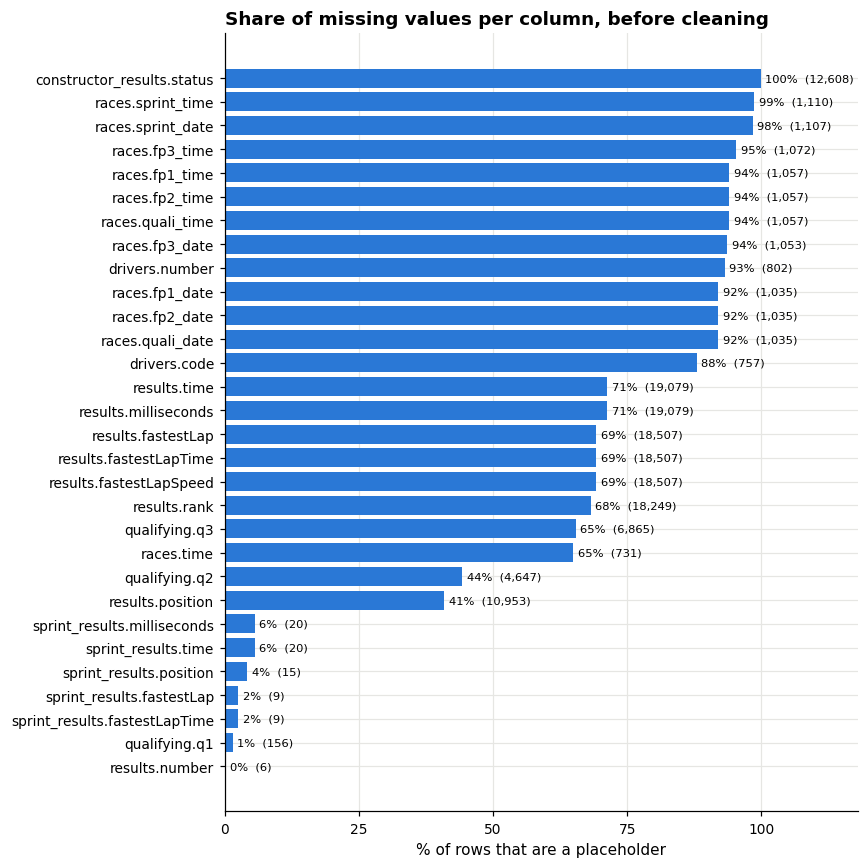

In [8]:
# For every column of every table: how many cells are a placeholder (\N or empty)?
missing_rows = []
for t, df in raw.items():
    for c in df.columns:
        n = int((df[c] == '\\N').sum() + (df[c] == '').sum())
        if n:
            missing_rows.append({'table': t, 'column': c, 'missing': n, 'share': n / len(df)})
missing_before = pd.DataFrame(missing_rows).sort_values('share')
print('Columns with at least one placeholder:', len(missing_before))

# One bar per column that has placeholders, labelled with the share and the count
fig, ax = plt.subplots(figsize=(8, 8))
labels = missing_before['table'] + '.' + missing_before['column']
bars = ax.barh(labels, missing_before['share'] * 100, color=BLUE)
ax.bar_label(bars, labels=[f'{s:.0%}  ({n:,})' for s, n in zip(missing_before['share'], missing_before['missing'])],
             padding=3, fontsize=7.5)
ax.set_xlim(0, 118); ax.set_xticks([0, 25, 50, 75, 100]); ax.set_xlabel('% of rows that are a placeholder')
ax.set_title('Share of missing values per column, before cleaning')
finish(fig, '03_missing_per_column')

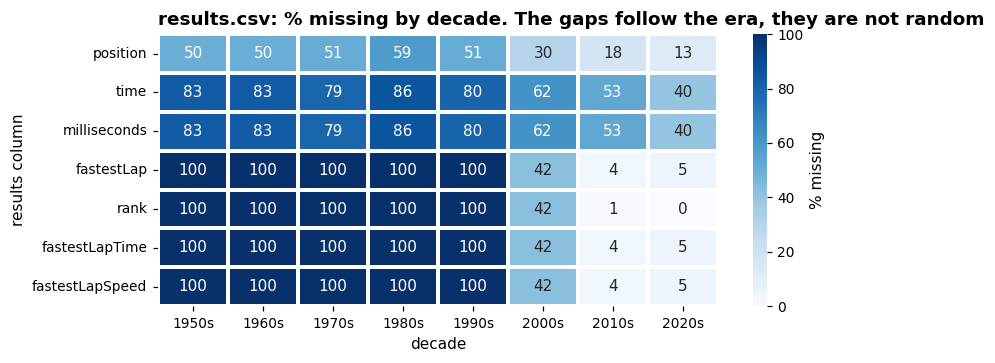

In [9]:
# Is the missingness random, or does it depend on the season? One heatmap answers that.
r_year = raw['results'].merge(raw['races'][['raceId', 'year']], on='raceId')
r_year['decade'] = (r_year['year'].astype(int) // 10 * 10).astype(str) + 's'
result_cols = ['position', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed']
heat = pd.DataFrame({c: (r_year[c] == '\\N').groupby(r_year['decade']).mean() for c in result_cols}).T * 100

fig, ax = plt.subplots(figsize=(8, 3.4))
sns.heatmap(heat, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': '% missing'}, linewidths=1.5,
            linecolor='white', vmin=0, vmax=100, ax=ax)
ax.set_xlabel('decade'); ax.set_ylabel('results column'); ax.grid(False)
ax.set_title('results.csv: % missing by decade. The gaps follow the era, they are not random')
finish(fig, '04_missing_by_decade')

**What we see**
- `position`, `time` and `milliseconds` are missing for cars that did not finish. That is not an error: a car that retired has no finishing time. The share shrinks over the decades because modern cars break down less.
- The fastest-lap columns are 100% missing before the 2000s and almost complete after. They were simply not recorded in old seasons.
- `q2` and `q3` are missing for many rows because of how knockout qualifying works: slow drivers are eliminated and never set a time in the later rounds.
- Almost all of these columns are filled in after the race, so they can never be features anyway. The missing values that matter for us are in `qualifying` and `grid`, and we look at those next.

So, we can observe that: **"Missingness has a pattern throughout the years (historical pattern)"**
This is an important conclusion that tells us that missingness is not always random, so, needs a certain type of cleaning (not just dropping with no reason).

In conclusion, we can say that missingness in this dataset is often systematic and meaningful. It reflects race outcomes, qualifying progression, and historical differences in data recording. Therefore, we must not blindly impute or delete missing values. We need column-specific treatment, especially for pre-race features such as qualifying information.

## 1.4 Primary keys

**What we do:** check that the key of every table is unique and never missing.

**Why:** a key identifies one row. If two rows share a key, a join multiplies rows without telling us.

In [10]:
# For each table: are there duplicate keys, and is any key cell a placeholder?
pk_report = []
for t, key in PRIMARY_KEYS.items():
    df = raw[t]
    pk_report.append({
        'table': t, 'primary key': ' + '.join(key), 'rows': len(df),
        'duplicate keys': int(df.duplicated(key).sum()),
        'missing keys': int(df[key].isin(['\\N', '']).any(axis=1).sum()),
    })
pk_report = pd.DataFrame(pk_report)
pk_report['OK'] = (pk_report['duplicate keys'] == 0) & (pk_report['missing keys'] == 0)
display(pk_report)
# Stop the notebook here if a key is broken: no join after this point could be trusted
assert pk_report['OK'].all(), 'A primary key is broken'
print('All 14 primary keys are unique and non-null.')

,table,primary key,rows,duplicate keys,missing keys,OK
0,circuits,circuitId,77,0,0,True
1,constructors,constructorId,212,0,0,True
2,drivers,driverId,861,0,0,True
3,races,raceId,1125,0,0,True
4,seasons,year,75,0,0,True
5,status,statusId,139,0,0,True
6,results,resultId,26759,0,0,True
7,qualifying,qualifyId,10494,0,0,True
8,sprint_results,resultId,360,0,0,True
9,driver_standings,driverStandingsId,34863,0,0,True


All 14 primary keys are unique and non-null.


## 1.5 Foreign keys
**What we do**: for every link in the table of 1.2, look for "orphans": values in the child table that do not exist in the parent table. This is an anti-join.

**Why**: an orphan row would be dropped by an inner join (we lose data) or get empty columns in a left join.

In [11]:
fk_report = []
for child, col, parent in FOREIGN_KEYS:
    orphans = ~raw[child][col].isin(raw[parent][col])          # anti-join: child value not found in parent
    fk_report.append({'child table': child, 'column': col, 'parent table': parent,
                      'rows checked': len(raw[child]), 'orphans': int(orphans.sum())})
fk_report = pd.DataFrame(fk_report)
display(fk_report)
assert fk_report['orphans'].sum() == 0, 'A foreign key does not reconcile'
print(f'All {len(fk_report)} foreign-key links reconcile: 0 orphans.')

,child table,column,parent table,rows checked,orphans
0,races,circuitId,circuits,1125,0
1,races,year,seasons,1125,0
2,results,raceId,races,26759,0
3,results,driverId,drivers,26759,0
4,results,constructorId,constructors,26759,0
5,results,statusId,status,26759,0
6,qualifying,raceId,races,10494,0
7,qualifying,driverId,drivers,10494,0
8,qualifying,constructorId,constructors,10494,0
9,sprint_results,raceId,races,360,0


All 23 foreign-key links reconcile: 0 orphans.


**What we see**: every one of the 23 links is clean. The dataset is well built as a database. Its problems are in the meaning of the rows, which is what the next checks are about.

## 1.6 Is there really one row per driver per race?
**Why**: our unit of analysis is "one driver entering one race". resultId is unique, but that is not the same thing. We need the pair (raceId, driverId) to be unique.

Rows that share (raceId, driverId) with another row: 176
Driver-race pairs affected: 85
Rows per affected pair: {2: 79, 3: 6}


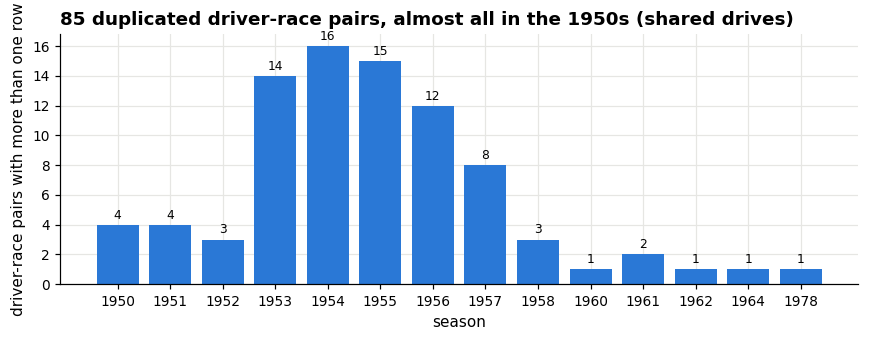

,resultId,year,name,driverId,number,grid,positionText,positionOrder,points,laps
18894,18895,1956,Argentine Grand Prix,579,30,1,R,13,0,22
20266,20267,1956,Argentine Grand Prix,579,34,3,1,1,5,98


In [12]:
# Add the season and the race name to every result row
res_raw = raw['results'].merge(raw['races'][['raceId', 'year', 'name']], on='raceId')
res_raw['year'] = res_raw['year'].astype(int)

# keep=False marks ALL rows of a repeated pair, not only the second one
is_dup = res_raw.duplicated(['raceId', 'driverId'], keep=False)
dup_rows = res_raw[is_dup]
n_groups = dup_rows.drop_duplicates(['raceId', 'driverId']).shape[0]
print(f'Rows that share (raceId, driverId) with another row: {len(dup_rows)}')
print(f'Driver-race pairs affected: {n_groups}')
print('Rows per affected pair:', dup_rows.groupby(['raceId', 'driverId']).size().value_counts().to_dict())

# Count each affected driver-race pair once, per season
by_year = dup_rows.drop_duplicates(['raceId', 'driverId']).groupby('year').size()
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.bar(by_year.index.astype(str), by_year.values, color=BLUE)
ax.bar_label(bars, fontsize=8, padding=2)
ax.set_ylabel('driver-race pairs with more than one row'); ax.set_xlabel('season')
ax.set_title(f'{n_groups} duplicated driver-race pairs, almost all in the 1950s (shared drives)')
finish(fig, '05_duplicates_by_year')

# One real example: Fangio at the 1956 Argentine Grand Prix
fangio = raw['drivers'].loc[raw['drivers']['driverRef'] == 'fangio', 'driverId'].iloc[0]
example = res_raw[(res_raw['driverId'] == fangio) & (res_raw['year'] == 1956) & (res_raw['name'] == 'Argentine Grand Prix')]
display(example[['resultId', 'year', 'name', 'driverId', 'number', 'grid', 'positionText', 'positionOrder', 'points', 'laps']])

**What we see**
- 85 driver-race pairs have more than one row (79 pairs with two rows, 6 with three), 176 rows in total.
- They sit in 1950 to 1964, plus one case in 1978. This matches what we know about the old shared-drives: in early F1, a driver whose car broke could take over a team mate's car, and the data stores one row per car he drove.
- The example shows it. Fangio started the 1956 Argentine GP from pole in car 30 and retired. He then took over car 34 (which had started 3rd) and won. Two rows, one driver, one race.

So, if we ask ourselves: 

**"Does the results table actually match our required ML grain of one row per (raceId, driverId)?"**

The answer is: **Not completely. Historical shared drives create 85 affected driver-race pairs, so this must be handled deliberately during cleaning.**

## 1.7 How the sport changed over 75 seasons

**Why:** our table covers 1950 to 2024. If the sport changed a lot, a pattern from 1960 may not hold in 2024. These charts are the evidence we point to later when we choose the training window and decide how to treat missing qualifying data.

So, we're dealing with 75 year of Formula 1. That's actually a huge period!!

F1 in 1950 is not statistically equivalent to F1 in 2024. There were major changes in: number of races per season, number of cars entering races, reliability, qualifying systems, race procedures, regulations, number of available drivers, and data recording practices.

Therefore, before building an ML model, we need to know:

**Are we treating 75 years of historical data as if they were generated under one consistent system?**

This subsection give us evidence

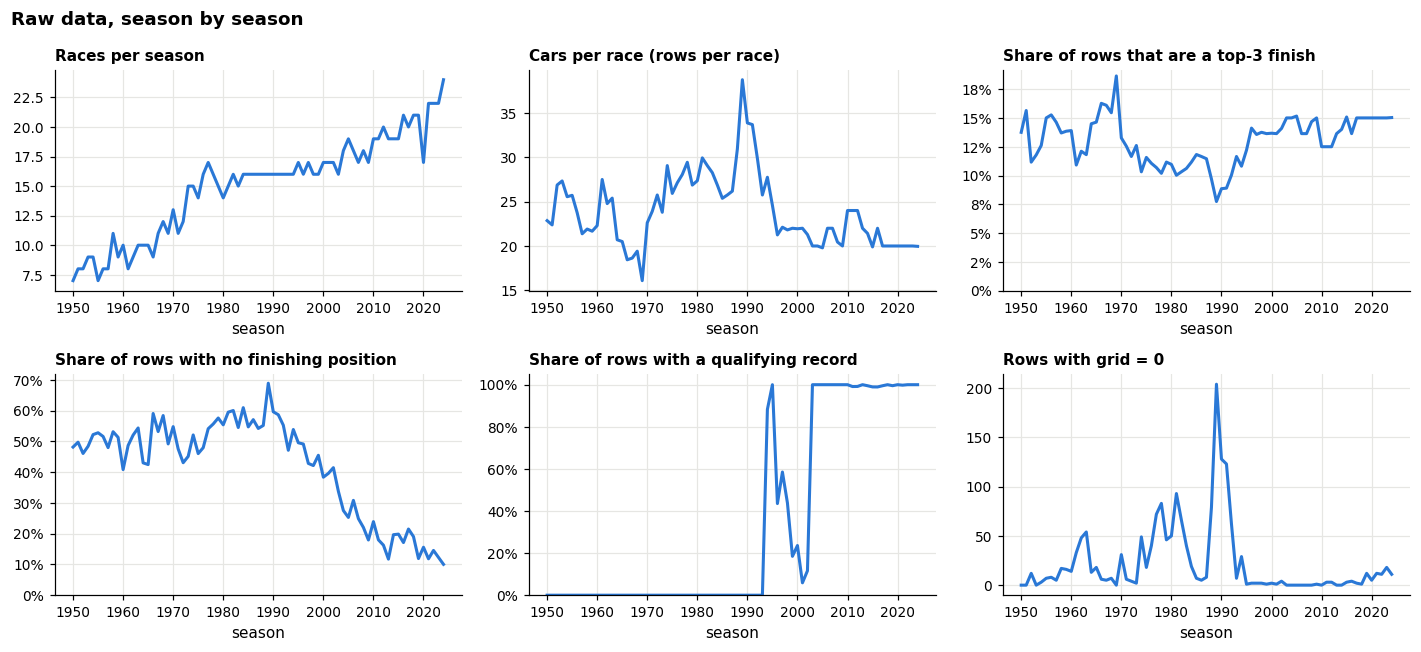

First season with any qualifying record: 1994


year,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006
quali_coverage,88%,100%,44%,59%,44%,18%,24%,6%,12%,100%,100%,100%,100%


In [13]:
def season_profile(results, qualifying):
    """One row per season with the numbers we want to track. Used before AND after cleaning."""
    r = results.copy()
    r['is_podium'] = r['positionOrder'].astype(float) <= 3
    r['classified'] = r['positionText'].astype(str).str.isdigit()        # has an official finishing position
    r['grid0'] = r['grid'].astype(float) == 0
    # does this (race, driver) pair have a row in the qualifying table?
    q_keys = set(zip(qualifying['raceId'].astype(int), qualifying['driverId'].astype(int)))
    r['has_quali'] = [k in q_keys for k in zip(r['raceId'].astype(int), r['driverId'].astype(int))]
    # one row per season
    g = r.groupby('year')
    return pd.DataFrame({
        'races': g['raceId'].nunique(),
        'rows_per_race': g.size() / g['raceId'].nunique(),
        'podium_share': g['is_podium'].mean(),
        'not_classified_share': 1 - g['classified'].mean(),
        'quali_coverage': g['has_quali'].mean(),
        'grid0_rows': g['grid0'].sum(),
    })

profile_before = season_profile(res_raw, raw['qualifying'])

# Six small charts, one per measurement. Shares are shown as percentages
panels = [('races', 'Races per season', 'races'),
          ('rows_per_race', 'Cars per race (rows per race)', 'rows'),
          ('podium_share', 'Share of rows that are a top-3 finish', 'share'),
          ('not_classified_share', 'Share of rows with no finishing position', 'share'),
          ('quali_coverage', 'Share of rows with a qualifying record', 'share'),
          ('grid0_rows', 'Rows with grid = 0', 'rows')]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (col, title, unit) in zip(axes.ravel(), panels):
    ax.plot(profile_before.index, profile_before[col], color=BLUE, lw=2)
    ax.set_title(title, fontsize=10); ax.set_xlabel('season')
    if unit == 'share':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
        ax.set_ylim(bottom=0)
fig.suptitle('Raw data, season by season', x=0.01, ha='left', weight='bold')
finish(fig, '06_season_profile_before')

print('First season with any qualifying record:', int(profile_before.index[profile_before['quali_coverage'] > 0].min()))
display(profile_before.loc[1994:2006, ['quali_coverage']].T.style.format('{:.0%}').set_caption('Qualifying coverage, 1994 to 2006'))

**What we see**
- **Calendar:** 7 races in 1950, 24 in 2024.
- **Field size:** 25 to 30 rows per race in the 1970s and 1980s, with a peak of almost 39 in 1989, and about 20 since the late 1990s. Those extra rows are mostly cars that showed up and failed to qualify.
- **Podium share:** always 3 per race, so the share moves with field size (about 8% in 1989, 15% now). Podiums are rare, which is why accuracy is a bad metric for this task: a model that always says "no" would be about 86% accurate and useless.
- **Reliability:** until about 1990, half of the rows or more have no finishing position. Today it is under 20%. A good grid slot was worth less when cars broke down so often.
- **Qualifying coverage:** the qualifying table starts in 1994. It is nearly complete in 1994 and 1995, patchy from 1996 to 2002 (as low as 6%), and complete from 2003. This is the "qualifying-coverage drift" the brief warns about, and it is bigger than we expected.
- **Grid = 0:** many rows up to the mid 1990s, then a small rise again after 2015. A grid position of 0 does not exist on a real grid, so this needs an explanation. We look into it in 1.8.

## 1.8 Columns that need a closer look

**What we do:** look at the value ranges and categories of the columns we plan to use.

**Why:** We need to check categories for inconsistent spellings and numeric columns for impossible values before trusting them.

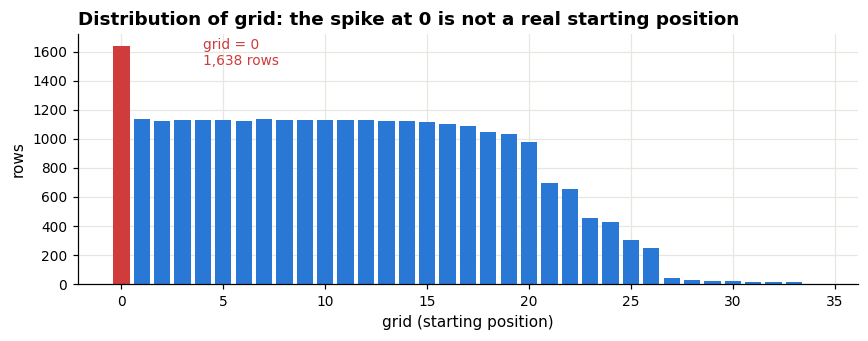

raced,completed 0 laps,completed at least 1 lap,All
outcome,,,
disqualified,6,0,6
excluded,7,0,7
failed to qualify,1348,0,1348
finished (has a position),0,60,60
retired,2,12,14
withdrawn,203,0,203
All,1566,72,1638


Seasons of the grid = 0 rows that completed laps: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [14]:
# --- (a) grid: a starting position of 0 is impossible on a real grid ---
grid = res_raw['grid'].astype(int)
fig, ax = plt.subplots(figsize=(8, 3.2))
# how many rows start from each grid value. The bar at 0 is drawn in red
counts = grid.value_counts().sort_index()
ax.bar(counts.index, counts.values, color=[RED if g == 0 else BLUE for g in counts.index])
ax.annotate(f'grid = 0\n{counts.loc[0]:,} rows', xy=(0, counts.loc[0]), xytext=(4, counts.loc[0] * 0.92), fontsize=9, color=RED)
ax.set_xlabel('grid (starting position)'); ax.set_ylabel('rows')
ax.set_title('Distribution of grid: the spike at 0 is not a real starting position')
finish(fig, '07_grid_distribution')

# Who are the grid = 0 rows? positionText tells us how the race ended for them.
POSITION_CODES = {'R': 'retired', 'D': 'disqualified', 'E': 'excluded', 'W': 'withdrawn',
                  'F': 'failed to qualify', 'N': 'not classified'}
res_raw['outcome'] = res_raw['positionText'].map(POSITION_CODES).fillna('finished (has a position)')
# Take only the grid = 0 rows and split them by whether the car completed any lap
grid0 = res_raw[grid == 0].copy()
grid0['raced'] = np.where(grid0['laps'].astype(int) > 0, 'completed at least 1 lap', 'completed 0 laps')
display(pd.crosstab(grid0['outcome'], grid0['raced'], margins=True))
print('Seasons of the grid = 0 rows that completed laps:', sorted(int(y) for y in grid0.loc[grid0['raced'] == 'completed at least 1 lap', 'year'].unique()))

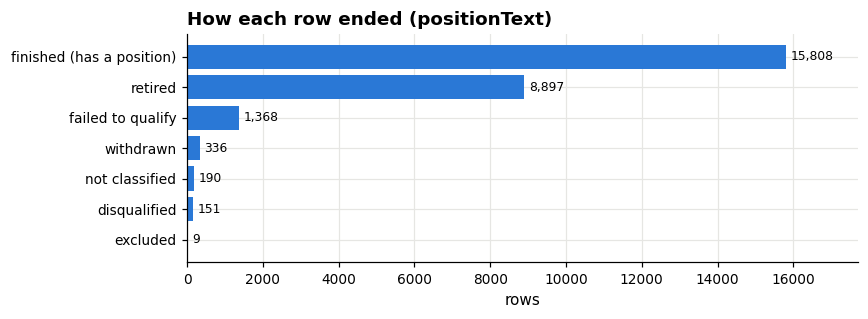

['Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'Hungary', 'India', 'Italy', 'Japan', 'Korea', 'Malaysia', 'Mexico', 'Monaco', 'Morocco', 'Netherlands', 'Portugal', 'Qatar', 'Russia', 'Saudi Arabia', 'Singapore', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'UAE', 'UK', 'USA', 'United States']

Circuit countries that look like the same place: ['USA', 'United States']

 ['American', 'American-Italian', 'Argentine', 'Argentine-Italian', 'Argentinian ', 'Australian', 'Austrian', 'Belgian', 'Brazilian', 'British', 'Canadian', 'Chilean', 'Chinese', 'Colombian', 'Czech', 'Danish', 'Dutch', 'East German', 'Finnish', 'French', 'German', 'Hungarian', 'Indian', 'Indonesian', 'Irish', 'Italian', 'Japanese', 'Liechtensteiner', 'Malaysian', 'Mexican', 'Monegasque', 'New Zealander', 'Polish', 'Portuguese', 'Rhodesian', 'Russian', 'South African', 'Spanish', 'Swedish', 'Swiss', 'Thai', 'Uruguayan', 'Venezuelan'

In [18]:
# --- (b) positionText codes over the whole table ---
codes = res_raw['outcome'].value_counts()
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(codes.index[::-1], codes.values[::-1], color=BLUE)
ax.bar_label(bars, labels=[f'{v:,}' for v in codes.values[::-1]], padding=3, fontsize=8)
ax.set_xlim(right=codes.max() * 1.12); ax.set_xlabel('rows')
ax.set_title('How each row ended (positionText)')
finish(fig, '08_position_codes')

# --- (c) inconsistent categories ---
countries = sorted(raw['circuits']['country'].unique())
print(countries)
print('\nCircuit countries that look like the same place:', [c for c in countries if c in ('USA', 'United States')])
nat = raw['drivers']['nationality']
nat_unique = sorted(raw['drivers']['nationality'].unique())
print('\n',nat_unique)
print('\nDriver nationalities with spaces at the start or end:', sorted(set(nat[nat != nat.str.strip()])))
print('Spellings for Argentina:', sorted(n for n in nat.unique() if n.startswith('Argentin')))
print('Spellings for America:', sorted(n for n in nat.unique() if n.startswith('America')))

# --- (d) time formats stored as text ---
print('\nExamples of time columns (all stored as text):')
print('  qualifying.q1        :', raw['qualifying']['q1'].iloc[:3].tolist())
print('  results.time         :', raw['results']['time'].iloc[:3].tolist(), '<- winner has a full time, others a gap')
print('  pit_stops.duration   :', sorted(raw['pit_stops']['duration'], key=len)[0], 'and', sorted(raw['pit_stops']['duration'], key=len)[-1])
print('  races.date           :', raw['races']['date'].iloc[0])

**What we see**
- **Grid = 0** covers 1,638 rows. Most of them (1,566) completed zero laps: they failed to qualify, withdrew, or were excluded before the race. They never had a place on the grid.
- 72 grid = 0 rows did complete laps, all from 2015 onwards. These are **pit-lane starts**: the car starts from the pit lane instead of a grid slot, usually after a penalty, and the dataset writes that as 0.
- So 0 means "no grid slot", never "ahead of pole". If we left it as a number, a model would read 0 as the best position there is.
- **Categories:** `circuits.country` has both "USA" and "United States". `drivers.nationality` has "Argentine" and "Argentinian " (with a space at the end). Both would break the home-race match in Question 2.
- **Times** are text in three different shapes (`1:26.572`, `26.898`, `+5.478`). They need to become numbers.

## 1.9 Audit summary

| # | Problem found | Evidence | Fixed in |
|---|---|---|---|
| 1 | Two placeholders for missing: `\N` and empty text | 1.1, 1.3 | 2.1 |
| 2 | Dates, numbers and lap times stored as text | 1.8 | 2.2 |
| 3 | Inconsistent country and nationality spellings | 1.8 | 2.2 |
| 4 | Indianapolis 500 rows (a different kind of race) | 2.3 | 2.3 |
| 5 | Rows for cars that never had a grid slot | 1.7, 1.8 | 2.4 |
| 6 | Grid = 0 used for pit-lane starts | 1.8 | 2.4 |
| 7 | 85 driver-race pairs with more than one row | 1.6 | 2.5 |
| 8 | Qualifying data missing before 1994 and patchy to 2002 | 1.7 | handled in features (5) and training window (7) |

Keys are fine: 14 primary keys valid, 23 foreign keys with 0 orphans.